# Combustion Flow Field Analysis using K-means Clustering

This notebook analyses a combustion flow field dataset by:
1. Loading and visualising physical quantities (Temperature, YOH, YH2)
2. Performing feature standardisation
3. Applying K-means clustering to identify distinct flow regions for chemistry integration

The dataset contains a 2D grid of combustion flow measurements including
temperature and species concentrations (YOH, YH2). The analysis helps
identify coherent structures in the combustion flow field.

**Data Structure**
- Information stored in `info.json`
- Grid coordinates stored in `X_m.dat` and `Y_m.dat`
- Physical quantities stored in separate `.dat` files

Data from: https://blastnet.github.io/sharma2024

## Load Metadata and Grid Coordinates

The metadata JSON file contains the grid dimensions `Nxyz`. Grid coordinates
are stored as little-endian 32-bit floats and reshaped to the 2D grid.

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans

# Load metadata containing grid dimensions
with open("dataset/info.json") as f:
    metadata = json.load(f)
Nx, Ny = metadata["global"]["Nxyz"]

# Import grid coordinates (X and Y positions)
# Data is stored in little-endian 32-bit float format
X = np.fromfile("dataset/grid/X_m.dat", dtype="<f4").reshape(Ny, Nx)
Y = np.fromfile("dataset/grid/Y_m.dat", dtype="<f4").reshape(Ny, Nx)

## Load Physical Quantities

Temperature (T), hydroxyl radical mass fraction (YOH), and hydrogen mass fraction (YH2)
are loaded from binary `.dat` files and transposed to match the grid layout.

In [2]:
# Load physical quantities (Temperature, YOH, YH2) and transpose to match grid dimensions
T = np.fromfile("dataset/data/T_K_id0100.dat", dtype="<f4").reshape(Nx, Ny).T
YOH = np.fromfile("dataset/data/YOH_id0100.dat", dtype="<f4").reshape(Nx, Ny).T
YH2 = np.fromfile("dataset/data/YH2_id0100.dat", dtype="<f4").reshape(Nx, Ny).T

## Visualise Physical Quantities

Side-by-side `pcolormesh` plots reveal the spatial distribution of temperature
and species concentrations across the 2D combustion flow field.

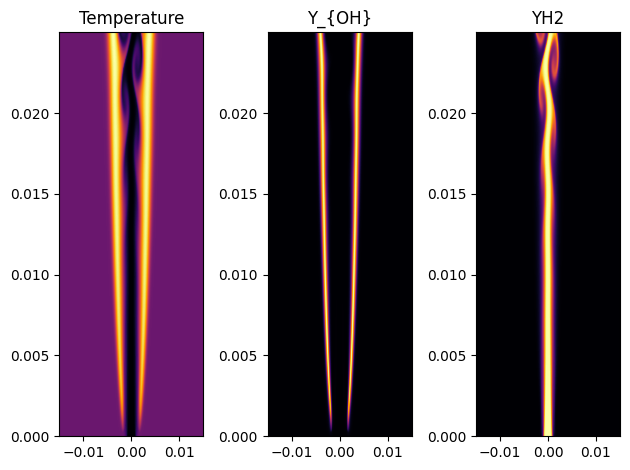

In [ ]:
# Create visualization of the three physical quantities
fig, ax = plt.subplots(1, 3)
# Plot Temperature
ax[0].set_title("Temperature")
ax[0].pcolormesh(Y, X, T, cmap="inferno")

# Plot YOH concentration
ax[1].set_title("YOH")
ax[1].pcolormesh(Y, X, YOH, cmap="inferno")

# Plot YH2 concentration
ax[2].set_title("YH2")
ax[2].pcolormesh(Y, X, YH2, cmap="inferno")
plt.tight_layout()
plt.show()

## Feature Engineering and Standardisation

All available `.dat` files are stacked into a feature matrix. Each feature is then
standardised (zero mean, unit variance) so that no single quantity dominates the
clustering due to scale differences.

In [4]:
# Import all available features from data directory
features = np.array([])
for feature in os.listdir("dataset/data"):
    if feature.endswith(".dat"):  # Process only .dat files
        if features.size == 0:  # For first feature
            features = np.fromfile(f"dataset/data/{feature}", dtype="<f4")
        else:  # Stack subsequent features vertically
            features = np.vstack((features, np.fromfile(f"dataset/data/{feature}", dtype="<f4")))

features = features.T  # Transpose to match grid dimensions

c = np.mean(features, axis=0)  # Compute mean of each feature
d = np.std(features, axis=0)   # Compute standard deviation of each feature
features = (features - c) / d

## K-means Clustering

K-means is applied with 8 clusters to segment the flow field into distinct
regions. The cluster labels are reshaped back to the 2D grid for spatial visualisation.

In [5]:
# Perform K-means clustering with 8 clusters
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
kmeans.fit(features)
colors = kmeans.labels_.reshape(Nx, Ny).T  # Reshape cluster labels to match grid

rng = np.random.RandomState(0)
indices = rng.permutation(len(features))[:100000]

## Visualise Clustering Results

The spatial cluster map shows the identified flow regions. The scatter plot in
temperature vs YOH space reveals how the clusters correspond to distinct
thermochemical states.

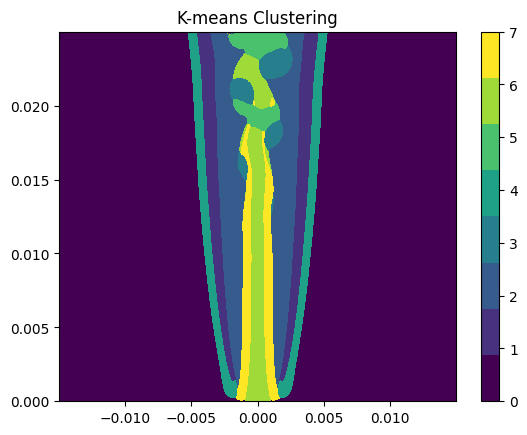

In [6]:
# Visualize clustering results
plt.title("K-means Clustering")
plt.pcolormesh(Y, X, colors, cmap=plt.get_cmap('viridis', n_clusters))
plt.colorbar()
plt.show()

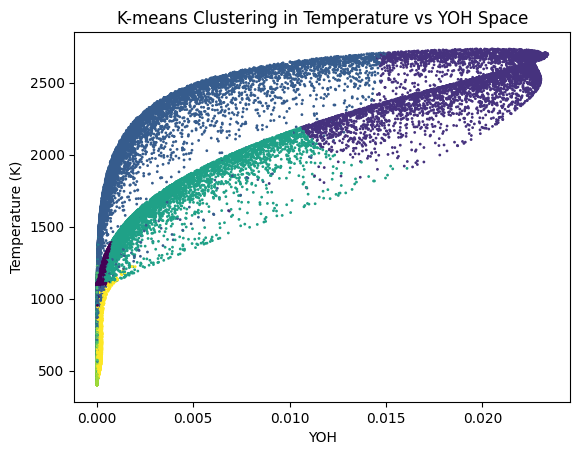

In [7]:
# Visualize results in temperature vs YOH space
plt.scatter(YOH.flatten()[indices], T.flatten()[indices], c=colors.flatten()[indices], cmap='viridis', s=1)
plt.xlabel("YOH")
plt.ylabel("Temperature (K)")
plt.title("K-means Clustering in Temperature vs YOH Space")
plt.show()